In [5]:
%%duckdb


SELECT 
  *, date_diff('minute', start_at, stop_at) AS duration_min
FROM (
  SELECT 
    * EXCLUDE (tripduration, starttime, stoptime),
    strptime(starttime, ['%m/%d/%Y %H:%M', '%m/%d/%Y %H:%M:%S', '%Y-%m-%d %H:%M:%S']) AS start_at,
    strptime(stoptime, ['%m/%d/%Y %H:%M', '%m/%d/%Y %H:%M:%S', '%Y-%m-%d %H:%M:%S']) AS stop_at
  FROM 's3://tt-bootcamp-shared/nyc-bike-trip/201[56]*.parquet'
)
LIMIT 3

,start station id,start station name,start station latitude,start station longitude,end station id,end station name,end station latitude,end station longitude,bikeid,usertype,birth year,gender,start_at,stop_at,duration_min
0,455,1 Ave & E 44 St,40.750020,-73.969053,265,Stanton St & Chrystie St,40.722293,-73.991475,18660,Subscriber,1960.0,2,2015-01-01 00:01:00,2015-01-01 00:24:00,23
1,434,9 Ave & W 18 St,40.743174,-74.003664,482,W 15 St & 7 Ave,40.739355,-73.999318,16085,Subscriber,1963.0,1,2015-01-01 00:02:00,2015-01-01 00:08:00,6
2,491,E 24 St & Park Ave S,40.740964,-73.986022,505,6 Ave & W 33 St,40.749013,-73.988484,20845,Subscriber,1974.0,1,2015-01-01 00:04:00,2015-01-01 00:10:00,6


## Problem 1: Trip duration

### Part 1: Build a Regression Model

Build a regression to predict trip duration by using
- Day of time
- Distance between start and end stations (there might be more than one way to measure it)
- Hour of day
- Weekend indicator
- Don't forget to model bias (this one is intentionally not used in lecture)
- Also any thing you want to end

### Part 2: Experiment Design

- Ensure that you properly design your experiment to report unbiased performance metric you choose

### Part 3 [Optional]: Visualize

- Generate some fictional pickup and dropoff locations for bike trips (random pair selection)
- Estimate trip duration for those say 10 trips
- Visualize them on map using `pydeck` by using redish color for slower trips and greener for faster trips.

## Veri Hazırlama
`hour_of_day , day_period (morning/midday/evening/night), weekend indicator, istasyonlar arası Manhattan mesafesi ve user_type feature'larını türetiyorum. 1 dakikanın altındaki kayıtları GPS hatası, 180 dakikanın üstündekileri ise bisikletin iade edilmediği durumlar olarak değerlendirip filtreliyorum. Koordinat bilgisi eksik kayıtları da dışarıda bırakıyorum. Ardından bu view'ı Polars DataFrame olarak belleğe yüklüyorum.`

In [1]:
import polars as pl

In [4]:
%%duckdb -t pl -o dataset

SELECT
    date_diff('minute', start_at, stop_at) AS duration_min,
    HOUR(start_at) AS hour_of_day,
    CASE
        WHEN HOUR(start_at) BETWEEN  5 AND  9 THEN 0 --morning
        WHEN HOUR(start_at) BETWEEN 10 AND 15 THEN 1 --midday
        WHEN HOUR(start_at) BETWEEN 16 AND 19 THEN 2 --evening
        ELSE                                       3 --night
    END AS day_period,
    DAYOFWEEK(start_at) AS day_of_week,
    CASE WHEN DAYOFWEEK(start_at) IN (0, 6) THEN 1 ELSE 0 END AS is_weekend,
    ((ABS("end station latitude"  - "start station latitude") * 111.0 + ABS("end station longitude" - "start station longitude") * 84.0)) AS dist_km,
    CASE WHEN usertype = 'Subscriber' THEN 1 ELSE 0 END AS is_subscriber
FROM (SELECT 
  *, date_diff('minute', start_at, stop_at) AS duration_min
FROM (
  SELECT 
    * EXCLUDE (tripduration, starttime, stoptime),
    strptime(starttime, ['%m/%d/%Y %H:%M', '%m/%d/%Y %H:%M:%S', '%Y-%m-%d %H:%M:%S']) AS start_at,
    strptime(stoptime, ['%m/%d/%Y %H:%M', '%m/%d/%Y %H:%M:%S', '%Y-%m-%d %H:%M:%S']) AS stop_at
  FROM 's3://tt-bootcamp-shared/nyc-bike-trip/201[56]*.parquet'
))
WHERE date_diff('minute', start_at, stop_at) BETWEEN 1 AND 180
  AND "start station latitude" IS NOT NULL
  AND "end station latitude"   IS NOT NULL

duration_min,hour_of_day,day_period,day_of_week,is_weekend,dist_km,is_subscriber
i64,i64,i32,i64,i32,f64,i32
23,0,3,4,0,4.961107,1
6,0,3,4,0,0.789031,1
6,0,3,4,0,1.100229,1
3,0,3,4,0,0.69334,1
16,0,3,4,0,2.358136,1
…,…,…,…,…,…,…
7,23,3,6,1,1.248343,1
17,23,3,6,1,2.205365,0
29,23,3,6,1,1.66143,1


## Model
`Veriyi %80 train, %20 test olarak ayırıyorum. Feature'lar arasında hour_of_day, day_period, is_weekend, day_of_week, dist_km ve is_subscriber bulunuyor. Hedef değişken olan trip süresini dakika cinsinden tahmin etmek için fit_intercept=True ile bias terimi modele eklenerek Linear Regresyon yapılıyor.`

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

FEATURES = ["hour_of_day", "day_period", "is_weekend", "day_of_week", "dist_km", "is_subscriber"]

X = dataset.select(FEATURES).to_numpy()
y = dataset["duration_min"].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model = LinearRegression(fit_intercept=True)
model.fit(X_train, y_train)

LinearRegression()

## Değerlendirme

In [6]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred = model.predict(X_test)

print(f"MSE  :{mean_squared_error(y_test, y_pred):.2f} dk")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.2f} dk")
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.2f} dk")
print(f"R²   : {r2_score(y_test, y_pred):.4f}")
print(f"Bias : {model.intercept_:.2f} dk")

MSE  :130.28 dk
RMSE : 11.41 dk
MAE  : 7.33 dk
R²   : 0.1201
Bias : 23.87 dk


### Problem 2: Extending Naive Bayesian

### Part 1: Expand the NB Regression Idea to continous variable

$$
P(gender = a, speed_{bike} = x) = P(gender = a) P(speed_{bike} = x | gender = a)
$$

- Note that $P(speed_{bike} = x | gender = a)$ is  continous distribution.
- Expand the idea
- Build a predictive model for estimation biker gender using the bike speed ?

### Part 2: Use Visualization to decide best distribution 

- How should be $P(speed_{bike} = x | gender = a)$ modeled

In [1]:
%%duckdb -o gender_1_duration


SELECT 
  *, date_diff('minute', start_at, stop_at) AS duration_min
FROM (
  SELECT 
    * EXCLUDE (tripduration, starttime, stoptime),
    strptime(starttime, ['%m/%d/%Y %H:%M', '%m/%d/%Y %H:%M:%S', '%Y-%m-%d %H:%M:%S']) AS start_at,
    strptime(stoptime, ['%m/%d/%Y %H:%M', '%m/%d/%Y %H:%M:%S', '%Y-%m-%d %H:%M:%S']) AS stop_at
  FROM 's3://tt-bootcamp-shared/nyc-bike-trip/201[56]*.parquet'
) where gender =1 
LIMIT 3

,start station id,start station name,start station latitude,start station longitude,end station id,end station name,end station latitude,end station longitude,bikeid,usertype,birth year,gender,start_at,stop_at,duration_min
0,434,9 Ave & W 18 St,40.743174,-74.003664,482,W 15 St & 7 Ave,40.739355,-73.999318,16085,Subscriber,1963.0,1,2015-01-01 00:02:00,2015-01-01 00:08:00,6
1,491,E 24 St & Park Ave S,40.740964,-73.986022,505,6 Ave & W 33 St,40.749013,-73.988484,20845,Subscriber,1974.0,1,2015-01-01 00:04:00,2015-01-01 00:10:00,6
2,384,Fulton St & Waverly Ave,40.683178,-73.965964,399,Lafayette Ave & St James Pl,40.688515,-73.964763,19610,Subscriber,1969.0,1,2015-01-01 00:04:00,2015-01-01 00:07:00,3


## Veri İnceleme 
- `Summarize fonksiyonu ile verinin istatistiksel özelliklerini çıkarıp incelemesini yapıyoruz.`

In [1]:
%%duckdb

summarize (SELECT 
  *, date_diff('minute', start_at, stop_at) AS duration_min
FROM (
  SELECT 
    * EXCLUDE (tripduration, starttime, stoptime),
    strptime(starttime, ['%m/%d/%Y %H:%M', '%m/%d/%Y %H:%M:%S', '%Y-%m-%d %H:%M:%S']) AS start_at,
    strptime(stoptime, ['%m/%d/%Y %H:%M', '%m/%d/%Y %H:%M:%S', '%Y-%m-%d %H:%M:%S']) AS stop_at
  FROM 's3://tt-bootcamp-shared/nyc-bike-trip/201[56]*.parquet'
))

,column_name,column_type,min,max,approx_unique,avg,std,q25,q50,q75,count,null_percentage
0,start station id,BIGINT,72,3440,836,878.1323107025237,1044.3774226020535,327,448,522,23783624,0.00
1,start station name,VARCHAR,1 Ave & E 15 St,York St & Jay St,646,None,None,None,None,None,23783624,0.00
2,start station latitude,DOUBLE,0.0,40.804213,759,40.73692042508271,0.027078942695619477,40.7212266622161,40.73803047759322,40.7522057767779,23783624,0.00
3,start station longitude,DOUBLE,-74.0313720703125,0.0,735,-73.98758094197959,0.030497853678378414,-73.99840326029636,-73.98925417075651,-73.97826407450701,23783624,0.00
4,end station id,BIGINT,72,3440,945,866.0839891347089,1034.282936698754,326,446,521,23783624,0.00
5,end station name,VARCHAR,1 Ave & E 15 St,York St & Jay St,646,None,None,None,None,None,23783624,0.00
6,end station latitude,DOUBLE,0.0,40.804213,786,40.736377304666945,0.10245766753944906,40.72104311186871,40.73757457716255,40.751880247356446,23783624,0.00
7,end station longitude,DOUBLE,-74.0836394,0.0,735,-73.98732804381608,0.18208191742329058,-73.99888822470338,-73.9894714378224,-73.97838665365201,23783624,0.00
8,bikeid,BIGINT,14529,27342,15156,20358.994452107047,3407.5946041738516,17424,20288,23164,23783624,0.00
9,usertype,VARCHAR,Customer,Subscriber,2,None,None,None,None,None,23783624,0.15


In [23]:
%%duckdb

select gender, count(1)from (SELECT 
  *, date_diff('minute', start_at, stop_at) AS duration_min
FROM (
  SELECT 
    * EXCLUDE (tripduration, starttime, stoptime),
    strptime(starttime, ['%m/%d/%Y %H:%M', '%m/%d/%Y %H:%M:%S', '%Y-%m-%d %H:%M:%S']) AS start_at,
    strptime(stoptime, ['%m/%d/%Y %H:%M', '%m/%d/%Y %H:%M:%S', '%Y-%m-%d %H:%M:%S']) AS stop_at
  FROM 's3://tt-bootcamp-shared/nyc-bike-trip/201[56]*.parquet'
))
group by gender

,gender,count(1)
0,2,4992728
1,0,2943420
2,1,15847476


## Hız Hesaplama
- `Manhattan mesafesi kullanarak (Derste bahsedilen NYC gibi şehirlerde karesel yapılaşmadan kaynaklı öklit mesafesi kullanılmadı) hız verisi hesaplandı.`
- `Ortalama normal bir bisiklet kullanım hızı 30 km/h olarak kısıt belirenedi.`
-  `duration_min değerleri pozitif olacak şekilde ve en fazla 180 olacak şekilde sınırlandı.`

In [4]:
import polars as pl

In [21]:
%%duckdb -t pl -o speed_data
SELECT
    gender,
    (ABS("end station latitude"  - "start station latitude") * 111.0 +
     ABS("end station longitude" - "start station longitude") * 84.0) /
    (date_diff('minute', start_at, stop_at) / 60.0) AS speed_kmh
FROM (
  SELECT 
    * EXCLUDE (tripduration, starttime, stoptime),
    strptime(starttime, ['%m/%d/%Y %H:%M', '%m/%d/%Y %H:%M:%S', '%Y-%m-%d %H:%M:%S']) AS start_at,
    strptime(stoptime, ['%m/%d/%Y %H:%M', '%m/%d/%Y %H:%M:%S', '%Y-%m-%d %H:%M:%S']) AS stop_at
  FROM 's3://tt-bootcamp-shared/nyc-bike-trip/201[56]*.parquet'
)
WHERE stop_at > start_at
  AND date_diff('minute', start_at, stop_at) BETWEEN 1 AND 180
  AND (ABS("end station latitude"  - "start station latitude") * 111.0 +
       ABS("end station longitude" - "start station longitude") * 84.0) > 0
  AND gender IN (1, 2)
  AND (ABS("end station latitude"  - "start station latitude") * 111.0 +
       ABS("end station longitude" - "start station longitude") * 84.0) /
      (date_diff('minute', start_at, stop_at) / 60.0) BETWEEN 1 AND 30

gender,speed_kmh
i64,f64
2,12.942018
1,7.890312
1,11.002286
1,13.86679
1,8.843012
…,…
2,10.700081
1,7.783641
2,3.437441


## Hız verisinin istatistiği çıkarıldı 

In [24]:
%%duckdb

summarize speed_data

,column_name,column_type,min,max,approx_unique,avg,std,q25,q50,q75,count,null_percentage
0,gender,BIGINT,1,2,2,1.2393243972908243,0.4266711134595191,1,1,1,20435146,0.0
1,speed_kmh,DOUBLE,1.000027595662895,29.999364600017344,1653787,11.92371649202963,3.884125840998504,9.361700101028124,11.737647503987182,14.339528833023955,20435146,0.0


## Veri Görselleştirme
- `Cinsiyetlere göre hız verisi grafiksel olarak çıkarıldı ve dağılım yapısı incelendi.`

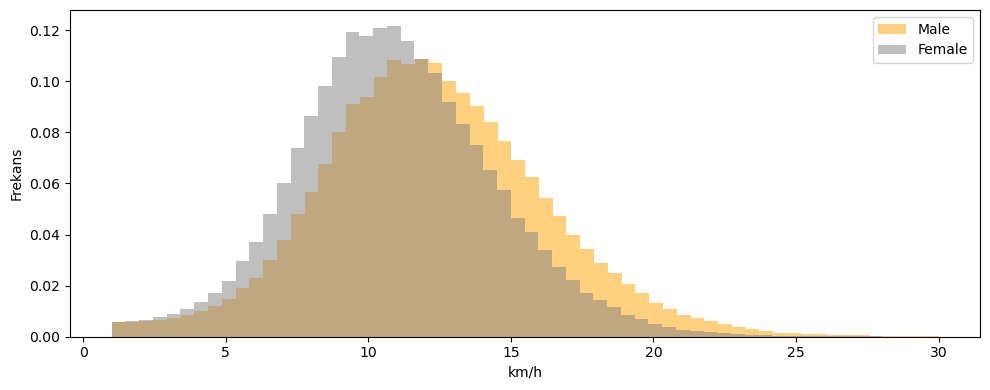

In [28]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))

for gender, label, color in [(1, "Male", "orange"), (2, "Female", "gray")]:
    data = speed_data.filter(pl.col("gender") == gender)["speed_kmh"].to_numpy()
    ax.hist(data, bins=60, alpha=0.5, label=label, color=color, edgecolor="none", density=True)

ax.set_xlabel("km/h")
ax.set_ylabel("Frekans")
ax.legend()
plt.tight_layout()
plt.show()

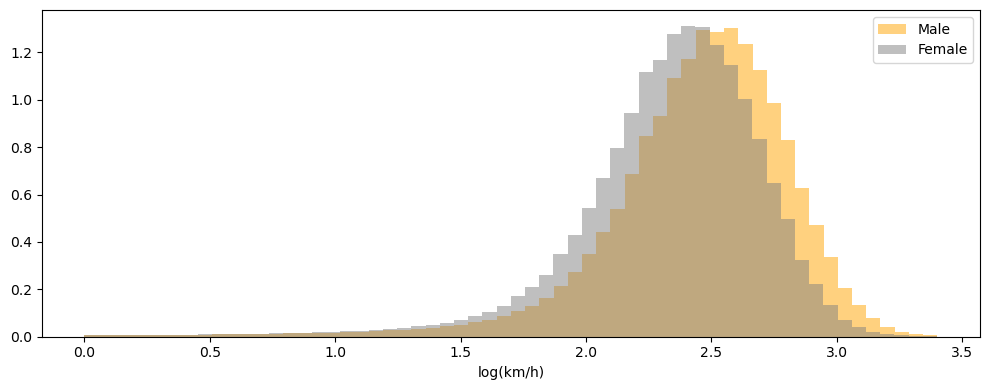

In [29]:
import numpy as np

fig, ax = plt.subplots(figsize=(10, 4))

for gender, label, color in [(1, "Male", "orange"), (2, "Female", "gray")]:
    data = np.log(speed_data.filter(pl.col("gender") == gender)["speed_kmh"].to_numpy())
    ax.hist(data, bins=60, alpha=0.5, label=label, color=color, density=True, edgecolor="none")

ax.set_xlabel("log(km/h)")
ax.legend()
plt.tight_layout()
plt.show()

## Train-Test Split ve Prior ve Posterior Probability Hesabı
- `Veri seti %80 - %20 olarak eğitim ve test seti olmak üzere ayrıldı`
- `Prior ve posterior olasılıklar hesaplandı.`
- `Olasılıklar 0'a giderken kaybolma problemi yaşamasını engellemek için logaritmanın doğası gereği çarpma işleminin parametrelerinin ayrı ayrı logaritmasının alıp toplanması aynı kapıya çıktığından logaritma alınarak bu problem engellendi.`
- `stratify parametresi ile eğitim seti ve test seti dağılımların cinsiyetlere göre aynı olması sağlandı.`

In [31]:
from sklearn.model_selection import train_test_split
import numpy as np

data = speed_data.to_numpy()
X = speed_data["speed_kmh"].to_numpy()
y = speed_data["gender"].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=speed_data["gender"])

params = {}
for gender, label in [(1, "Male"), (2, "Female")]:
    speed = X_train[y_train == gender]
    mu    = np.mean(np.log(speed))
    sigma = np.std(np.log(speed))
    params[gender] = {"mu": mu, "sigma": sigma}

total  = len(y_train)
prior  = {g: np.sum(y_train == g) / total for g in [1, 2]}



## Test

In [32]:
def predict_gender(speed):
    scores = {}
    for gender in [1, 2]:
        mu    = params[gender]["mu"]
        sigma = params[gender]["sigma"]
        log_likelihood = -np.log(speed) - np.log(sigma) - 0.5 * ((np.log(speed) - mu) / sigma) ** 2
        scores[gender] = np.log(prior[gender]) + log_likelihood
    return 1 if scores[1] > scores[2] else 2

y_pred = np.array([predict_gender(x) for x in X_test])
accuracy = np.mean(y_pred == y_test)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.7607
